In [1]:
# Dataset directory check

import os

data_dir = "dataset"

if not os.path.exists(data_dir):
    print("Dataset folder not found!")
    print("Please download dataset from the link in README and place it in the project directory.")
else:
    print("Dataset found. Proceeding...")

Dataset found. Proceeding...


In [4]:
# load datset

import pandas as pd

# Load dataset
df = pd.read_csv("dataset/customer_support_text_classification.csv")

# Preview
df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


Task 1: Dataset Understanding

In [ ]:
# Number of Records

print("Number of records:", df.shape[0])
print("Number of columns:", df.shape[1])

# target labels/classes

print("\nTarget classes:", df['sentiment_label'].unique())
print("\nClass distribution:\n", df['sentiment_label'].value_counts())

# Sample text records
print("\nSample messages:\n")
print(df['customer_message'].head(5), "\n")

# Average Text Length
df['text_length'] = df['customer_message'].apply(lambda x: len(str(x).split()))

print("Average text length:", df['text_length'].mean())


Number of records: 1500
Number of columns: 7

Target classes: <StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

Class distribution:
 sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Sample messages:

0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: str 

Average text length: 12.722666666666667


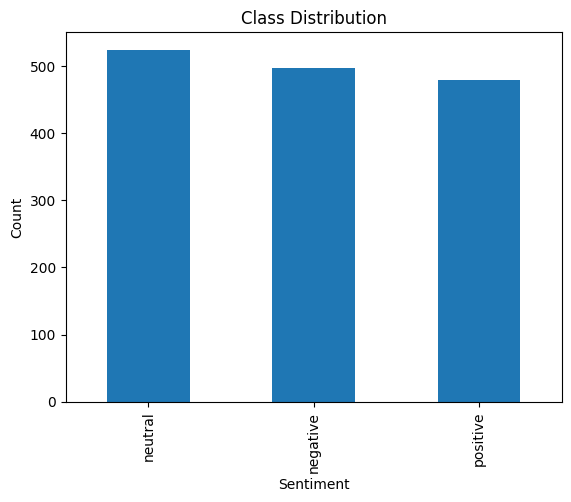

In [11]:
#Class distribution
import matplotlib.pyplot as plt

df['sentiment_label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# Task 2: Text Preprocessing

In [13]:
# import libraries

import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ekta1\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [14]:
# Text Cleaning Function
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()  # Lowercase
    
    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenization
    words = text.split()
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

In [15]:
# apply cleaning

df['cleaned_text'] = df['customer_message'].apply(clean_text)

# View sample
print(df[['customer_message', 'cleaned_text']].head())

                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                        cleaned_text  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  


In [17]:
# tokenization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['cleaned_text'])

sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

# padding Sequences
MAX_LEN = 50

X_padded = pad_sequences(sequences, maxlen=MAX_LEN, padding='post')

print("Sample padded sequence:\n", X_padded[0])

Sample padded sequence:
 [ 14 104  64  18   1   2   3   4   5   6   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


Task 3: Text Vectorization

In [18]:
#TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['cleaned_text'])

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (1500, 146)


In [21]:
# Convert Target Variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df['sentiment_label'])

print("Encoded classes:", le.classes_)
print("Sample encoded labels:", y[:10])

Encoded classes: ['negative' 'neutral' 'positive']
Sample encoded labels: [1 1 2 0 1 1 2 1 1 0]


In [22]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train_tfidf.shape)
print("X_test shape:", X_test_tfidf.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1200, 146)
X_test shape: (300, 146)
y_train shape: (1200,)
y_test shape: (300,)


Task 4: Baseline Model

In [24]:
# Train Model
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=200)

model_lr.fit(X_train_tfidf, y_train)

# Make prediction
y_pred = model_lr.predict(X_test_tfidf)

print("Sample predictions:", y_pred[:10])

Sample predictions: [1 2 1 0 0 0 0 1 0 0]


In [25]:
# Evaluate Model
from sklearn.metrics import accuracy_score, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       104
           2       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



Confusion Matrix:
 [[109   0   0]
 [  0 104   0]
 [  0   0  87]]


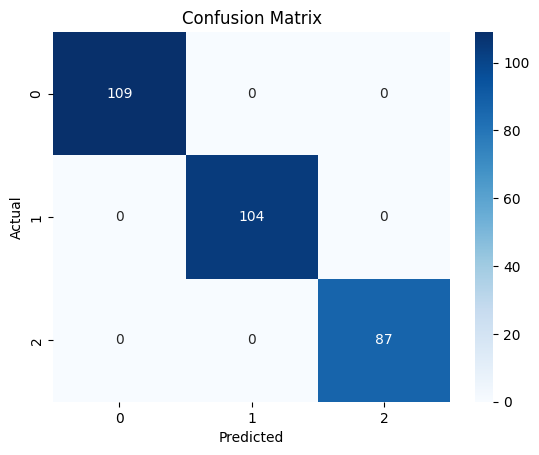

In [26]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Task 5: Sequence Model or Conceptual Architecture

In [27]:
from sklearn.model_selection import train_test_split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_padded, y, test_size=0.2, random_state=42
)

In [33]:
# Build LSTM Model
from tensorflow import keras
from tensorflow.keras import layers

vocab_size = 5000
embedding_dim = 64

model_lstm = keras.Sequential([
    
    # Input + Embedding
    layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    
    # LSTM Layer
    layers.LSTM(64),
    
    # Dense Layer
    layers.Dense(32, activation='relu'),
    
    # Output Layer (3 classes)
    layers.Dense(3, activation='softmax')
])

# Compile Model
model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train

history = model_lstm.fit(
    X_train_seq, y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# evaluate
loss, acc = model_lstm.evaluate(X_test_seq, y_test_seq)

print("\nLSTM Accuracy:", acc)
print("LSTM Loss:", loss)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.3385 - loss: 1.0999 - val_accuracy: 0.3292 - val_loss: 1.1023
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3552 - loss: 1.0991 - val_accuracy: 0.3292 - val_loss: 1.1005
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3552 - loss: 1.0982 - val_accuracy: 0.3292 - val_loss: 1.0988
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3375 - loss: 1.0989 - val_accuracy: 0.3292 - val_loss: 1.0991
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3552 - loss: 1.0981 - val_accuracy: 0.3292 - val_loss: 1.0997
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3467 - loss: 1.0985

LSTM Accuracy: 0.3466666638851166
LSTM Loss: 1.0984537601470947


*** Sequence Model (LSTM) ***

A sequence-based deep learning model was built using LSTM (Long Short-Term Memory) to capture word order and contextual relationships in text.

## Model Architecture
-- Input Sequence
Text is converted into sequences of integers using a tokenizer
Sequences are padded to a fixed length of 50
-- Embedding Layer
Converts each word index into a dense vector representation
Captures semantic meaning of words
-- LSTM Layer
Processes sequences step-by-step
Captures dependencies and context in text
Useful for understanding sentence structure
-- Dense Layer
Learns higher-level features from LSTM output
-- Output Layer
3 neurons with softmax activation
Predicts sentiment class (positive, neutral, negative)

## Model Configuration
Loss Function: Sparse Categorical Crossentropy
Optimizer: Adam
Evaluation Metric: Accuracy

## Key Advantage
Unlike TF-IDF, LSTM considers word order and context
This makes it more suitable for sequence-based tasks like NLP

Task 6: Attention and Transformer Reflection

*** Why RNNs Struggle with Long-Term Dependencies

Recurrent Neural Networks (RNNs) process text sequentially, one word at a time.
However, they struggle to retain information from earlier parts of long sequences.

-- As sequences get longer, earlier information gets “forgotten”
-- This is due to problems like **vanishing gradients**, where the influence of earlier words diminishes over time

In simple terms:
RNNs have difficulty remembering important information from far back in a sentence.


*** How LSTMs Help with Memory

LSTMs (Long Short-Term Memory networks) are designed to overcome this limitation.

-- They use **gates** (input, forget, output) to control what information to keep or discard
-- This allows them to retain important information for longer sequences

In simple terms:
LSTMs act like a “smart memory system” that decides what to remember and what to forget.

*** What Attention Solves

Attention mechanisms allow the model to focus on the most relevant parts of the input sequence when making predictions.

-- Instead of relying only on the last hidden state, attention looks at **all words in the sequence**
-- It assigns importance (weights) to different words

Example:
In a sentence, the model can focus more on words like *“not”* or *“urgent”* when determining sentiment.

In simple terms:
Attention helps the model “look back” at important words instead of forgetting them.


*** Why Transformers Are Important

Transformers are modern architectures that rely entirely on attention mechanisms.

-- They process all words in parallel (faster than RNNs)
-- They capture long-range dependencies effectively
-- They are the foundation of modern NLP models like GPT and BERT

In simple terms:
Transformers understand context better and work faster, making them the backbone of modern NLP and Generative AI.


*** Summary

-- RNNs struggle with long sequences
-- LSTMs improve memory using gated mechanisms
-- Attention helps focus on important parts of input
-- Transformers use attention to achieve state-of-the-art performance in NLP
